In [1]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
!git clone https://github.com/BennyTMT/LLMsForTimeSeries.git
%cd /kaggle/working/LLMsForTimeSeries/PAttn

Cloning into 'LLMsForTimeSeries'...
remote: Enumerating objects: 693, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 693 (delta 43), reused 4 (delta 3), pack-reused 613 (from 1)
Receiving objects: 100% (693/693), 3.90 MiB | 28.33 MiB/s, done.
Resolving deltas: 100% (380/380), done.
/kaggle/working/LLMsForTimeSeries/PAttn


In [3]:
!pip install -q pandas numpy scikit-learn matplotlib tqdm statsmodels

In [4]:
!find /kaggle/input -name "*.csv"

/kaggle/input/datasets/trongmanh/btcusdt-15m-calf-csv/BTCUSDT_15m_calf.csv
/kaggle/input/datasets/trongmanh/ettm2-csv/ETTm2.csv


In [5]:
!mkdir -p dataset/BTC

!cp /kaggle/input/datasets/trongmanh/btcusdt-15m-calf-csv/BTCUSDT_15m_calf.csv \
dataset/BTC/BTCUSDT_15m_calf.csv

In [6]:
!ls dataset/BTC

BTCUSDT_15m_calf.csv


In [7]:
import pandas as pd

raw_path = "dataset/BTC/BTCUSDT_15m_calf.csv"
out_path = "dataset/BTC/BTCUSDT_15m_pattn.csv"

df = pd.read_csv(raw_path)

if "date" not in df.columns:
    for col in ["timestamp", "time", "datetime", "open_time"]:
        if col in df.columns:
            df = df.rename(columns={col: "date"})
            break

df["date"] = pd.to_datetime(df["date"])

cols = [
    "date",
    "open",
    "high",
    "low",
    "volume",
    "quote_volume",
    "number_of_trades",
    "close"
]

df = df[cols].dropna().sort_values("date")

for c in cols:
    if c != "date":
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna()
df.to_csv(out_path, index=False)

print(df.shape)
df.head()

(70177, 8)


,date,open,high,low,volume,quote_volume,number_of_trades,close
0,2024-01-01 00:00:00,42283.58,42488.09,42261.02,431.71082,1.830469e+07,16651,42488.00
1,2024-01-01 00:15:00,42488.00,42554.57,42412.02,392.24889,1.666186e+07,13332,42419.73
2,2024-01-01 00:30:00,42419.73,42447.82,42354.19,319.90644,1.356409e+07,10959,42441.32
3,2024-01-01 00:45:00,42441.32,42490.74,42422.45,127.81493,5.426608e+06,6192,42475.23
4,2024-01-01 01:00:00,42475.23,42475.23,42431.65,188.76099,8.013008e+06,7256,42466.33


In [8]:
!sed -i 's/return mse, mae/return mse, mae, preds, trues/g' utils/tools.py

In [9]:
path = "main.py"

with open(path, "r") as f:
    text = f.read()

old = """mse, mae = test(model, test_data, test_loader, args, device, ii)
    mses.append(round(mse,5))
    maes.append(round(mae,5))"""

new = """mse, mae, preds, trues = test(model, test_data, test_loader, args, device, ii)

    np.save("pattn_pred.npy", preds)
    np.save("pattn_true.npy", trues)

    print("Prediction files saved: pattn_pred.npy, pattn_true.npy")

    mses.append(round(mse, 5))
    maes.append(round(mae, 5))"""

text = text.replace(old, new)

with open(path, "w") as f:
    f.write(text)

In [10]:
!sed -i 's/np.Inf/np.inf/g' utils/tools.py

In [13]:
!python main.py \
  --model_id BTC_PAttn_l2loss_sl512_pl24_v3_longtrain \
  --model PAttn \
  --root_path ./dataset/BTC/ \
  --data_path BTCUSDT_15m_pattn.csv \
  --data custom \
  --features M \
  --target close \
  --seq_len 512 \
  --label_len 0 \
  --pred_len 24 \
  --enc_in 7 \
  --c_out 7 \
  --freq 0 \
  --patch_size 16 \
  --stride 8 \
  --learning_rate 0.0001 \
  --train_epochs 50 \
  --decay_fac 0.5 \
  --d_model 768 \
  --n_heads 4 \
  --d_ff 768 \
  --dropout 0.2 \
  --patience 10 \
  --percent 100 \
  --gpt_layer 6 \
  --itr 1 \
  --tmax 50 \
  --cos 1 \
  --method PAttn \
  --gpu_loc 0 \
  --is_gpt 1 \
  --save_file_name pattn_btc_results_pl24_v3.txt | tee pattn_btc_train_pl24_v3.log

BTC_PAttn_l2loss_sl512_pl24_v3_longtrain
(49123, 7)
(7531, 7)
(14547, 7)
cuda:0
94it [01:42,  1.09s/it]
BTCUSDT_15m_pattn.csv torch.Size([512, 7, 512]) torch.Size([512, 7, 24])
Epoch: 1 cost time: 102.95894837379456
13it [00:06,  2.12it/s]
Epoch: 1, Steps: 94 | Train Loss: 0.3523781 Vali Loss: 0.1261237
lr = 0.0000999013
Validation loss decreased (inf --> 0.126124).  Saving model ...
94it [01:48,  1.15s/it]
Epoch: 2 cost time: 108.47156643867493
13it [00:05,  2.19it/s]
Epoch: 2, Steps: 94 | Train Loss: 0.3215120 Vali Loss: 0.1259278
lr = 0.0000996058
Validation loss decreased (0.126124 --> 0.125928).  Saving model ...
94it [01:49,  1.16s/it]
Epoch: 3 cost time: 109.25158286094666
13it [00:05,  2.18it/s]
Epoch: 3, Steps: 94 | Train Loss: 0.3179449 Vali Loss: 0.1250419
lr = 0.0000991145
Validation loss decreased (0.125928 --> 0.125042).  Saving model ...
94it [01:49,  1.16s/it]
Epoch: 4 cost time: 109.34015369415283
13it [00:05,  2.18it/s]
Epoch: 4, Steps: 94 | Train Loss: 0.3133484 Vali

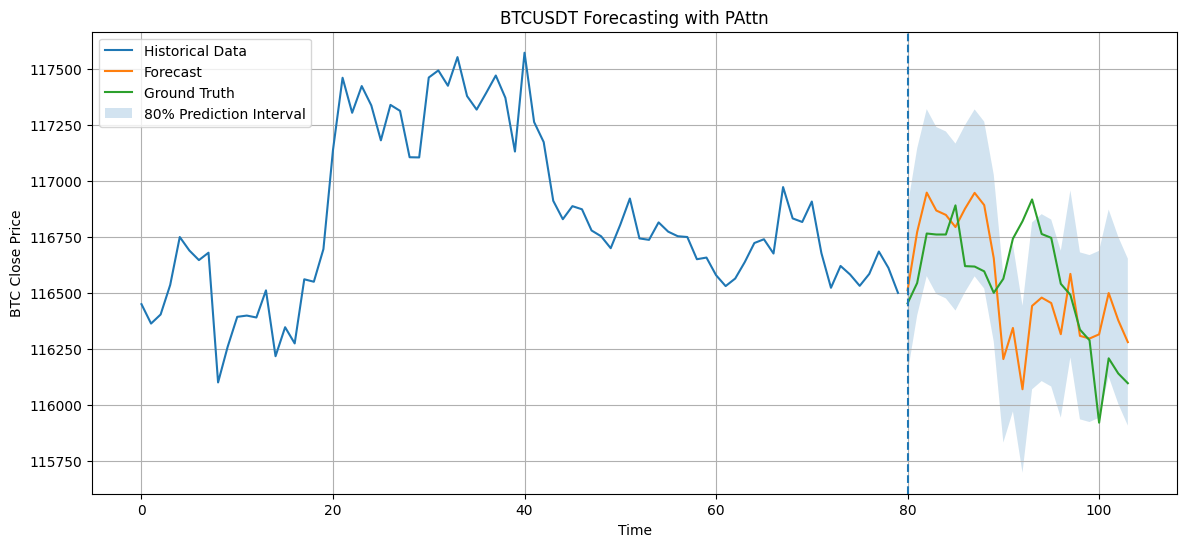

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pred = np.load("pattn_pred.npy")
true = np.load("pattn_true.npy")

df = pd.read_csv("dataset/BTC/BTCUSDT_15m_pattn.csv")
close_data = df["close"].values

sample_id = 60
feature_id = -1

seq_len = 512
pred_len = pred.shape[-1]

# Với Dataset_Custom thường test bắt đầu ở khoảng 80% cuối dataset
num_train = int(len(df) * 0.7)
num_test = int(len(df) * 0.2)
border1_test = len(df) - num_test - seq_len

start_idx = border1_test + sample_id

# Historical thật: 512 timestep trước dự báo
history_full = close_data[start_idx : start_idx + seq_len]

# Ground truth thật: pred_len timestep sau historical
future_true = close_data[start_idx + seq_len : start_idx + seq_len + pred_len]

# Forecast từ model
forecast_raw = pred[sample_id, feature_id, :]

# Scale forecast để giữ shape dự đoán nhưng đưa về vùng giá thật
forecast = (forecast_raw - forecast_raw.mean()) / (forecast_raw.std() + 1e-8)
forecast = forecast * future_true.std() + future_true.mean()

# Chỉ vẽ 80 timestep cuối cho dễ nhìn
show_hist = 80
history = history_full[-show_hist:]

std = np.std(forecast - future_true)
lower = forecast - 1.28 * std
upper = forecast + 1.28 * std

x_hist = np.arange(show_hist)
x_future = np.arange(show_hist, show_hist + pred_len)

plt.figure(figsize=(14,6))

plt.plot(x_hist, history, label="Historical Data")
plt.plot(x_future, forecast, label="Forecast")
plt.plot(x_future, future_true, label="Ground Truth")
plt.fill_between(x_future, lower, upper, alpha=0.2, label="80% Prediction Interval")

plt.axvline(show_hist, linestyle="--")

plt.title("BTCUSDT Forecasting with PAttn")
plt.xlabel("Time")
plt.ylabel("BTC Close Price")
plt.legend()
plt.grid(True)
plt.show()
